# Probabilistic Pruning Validation Interactive Notebook

This notebook validates all probabilistic pruning strategies in LearnM8:
- ProbabilisticPruner
- UncertaintyThresholdPruner
- PredictionThresholdPruner
- ConfidenceIntervalPruner

Tests are performed on multiple molecular datasets (FEN1, ADA, HIVPR) with comprehensive visualization and error handling.

In [1]:
# Cell 1: Imports & Configuration
import sys
import warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import logging
from datetime import datetime
import time

# Jupyter notebook configuration
%matplotlib inline
%load_ext autoreload
%autoreload 2

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Add project root to path
PROJECT_ROOT = Path().resolve().parent.parent
sys.path.append(str(PROJECT_ROOT))

from validation.create_embedding_plots import create_embedding_plots
from validation.data_loading import setup_data_with_error_handling

# LearnM8 imports
from learnm8.oracles import CSVOracle
from learnm8.core.data_manager import DataManager
from learnm8.learners.ensemble import RFEnsemble
from learnm8.pruning import (
    ProbabilisticPruner,
    UncertaintyThresholdPruner,
    PredictionThresholdPruner,
    ConfidenceIntervalPruner
)
from learnm8.utils.data_loaders import load_benchmark_data

# Setup logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

✅ Visualization function defined
✅ Data setup function defined


In [2]:
# Cell 2: Configuration
print("🔧 Configuration and Dataset Selection")
print("=" * 50)

# Define datasets to test
DATASETS = {
    # "FEN1": {
    #     "path": "/home/tony/LearnM8/data/FEN1_5fv7_scoring_and_consensus_maxAL_with_activity.csv",
    #     "target_column": "CHEMPLP"
    # },
    "ADA": {
        "path": "/home/tony/LearnM8/ESSENCE_benchmark_input/ADA.csv",
        "target_column": "Activity"
    },
    "HIVPR": {
        "path": "/home/tony/LearnM8/ESSENCE_benchmark_input/HIVPR.csv",
        "target_column": "Activity"
    }
}

# Pruning configurations
PRUNING_CONFIGS = {
    "ProbabilisticPruner": {
        "class": ProbabilisticPruner,
        "params": {"prune_fraction": 0.3}
    },
    "UncertaintyThresholdPruner": {
        "class": UncertaintyThresholdPruner,
        "params": {"uncertainty_threshold": 0.5}
    },
    "PredictionThresholdPruner": {
        "class": PredictionThresholdPruner,
        "params": {"prediction_threshold": 0.2}
    },
    "ConfidenceIntervalPruner": {
        "class": ConfidenceIntervalPruner,
        "params": {"confidence_level": 0.95}
    }
}

print(f"📊 Datasets: {list(DATASETS.keys())}")
print(f"🔧 Pruning strategies: {list(PRUNING_CONFIGS.keys())}")
print(f"📁 Results will be saved to plots_{{dataset_name}} directories")

🔧 Configuration and Dataset Selection
📊 Datasets: ['ADA', 'HIVPR']
🔧 Pruning strategies: ['ProbabilisticPruner', 'UncertaintyThresholdPruner', 'PredictionThresholdPruner', 'ConfidenceIntervalPruner']
📁 Results will be saved to plots_{dataset_name} directories


In [3]:
# Cell 3: Pruning Visualization Function
def create_pruning_plots(embeddings, predictions, uncertainties, pruned_indices, retained_indices, 
                        ground_truth, method_name, output_dir, timing_info):
    """
    Create comprehensive pruning visualization plots.
    
    Args:
        embeddings: 2D embedding coordinates
        predictions: Model predictions
        uncertainties: Model uncertainties (can be None)
        pruned_indices: Indices of pruned compounds
        retained_indices: Indices of retained compounds
        ground_truth: True values
        method_name: Name of the pruning method
        output_dir: Directory to save plots
        timing_info: Dictionary with timing information
    """
    logger.info(f"Creating pruning plots for {method_name}")
    output_dir = Path(output_dir)
    output_dir.mkdir(exist_ok=True)
    
    # Set up the plot style
    plt.style.use('default')
    
    # Create figure with 4 subplots (2x2)
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.flatten()
    
    # Plot 1: Compounds colored by predictions
    scatter1 = axes[0].scatter(embeddings[:, 0], embeddings[:, 1], 
                              c=predictions, alpha=0.6, s=20, cmap='viridis')
    axes[0].set_title(f"Compounds Colored by Predictions")
    axes[0].set_xlabel("Component 1")
    axes[0].set_ylabel("Component 2")
    axes[0].grid(True, alpha=0.3)
    plt.colorbar(scatter1, ax=axes[0], label='Prediction')
    
    # Plot 2: Compounds colored by uncertainty (if available)
    if uncertainties is not None and len(uncertainties) > 0:
        scatter2 = axes[1].scatter(embeddings[:, 0], embeddings[:, 1], 
                                  c=uncertainties, alpha=0.6, s=20, cmap='plasma')
        axes[1].set_title(f"Compounds Colored by Uncertainty")
        plt.colorbar(scatter2, ax=axes[1], label='Uncertainty')
    else:
        axes[1].scatter(embeddings[:, 0], embeddings[:, 1], alpha=0.6, s=20, c='gray')
        axes[1].set_title(f"Compounds (No Uncertainty Available)")
    axes[1].set_xlabel("Component 1")
    axes[1].set_ylabel("Component 2")
    axes[1].grid(True, alpha=0.3)
    
    # Plot 3: Pruned vs retained compounds
    if len(retained_indices) > 0:
        axes[2].scatter(embeddings[retained_indices, 0], embeddings[retained_indices, 1], 
                       alpha=0.6, s=20, color='green', label=f'Retained ({len(retained_indices)})')
    if len(pruned_indices) > 0:
        axes[2].scatter(embeddings[pruned_indices, 0], embeddings[pruned_indices, 1], 
                       alpha=0.4, s=20, color='red', label=f'Pruned ({len(pruned_indices)})')
    axes[2].set_title(f"Pruned vs Retained Compounds")
    axes[2].set_xlabel("Component 1")
    axes[2].set_ylabel("Component 2")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    # Plot 4: Statistics and timing information
    axes[3].axis('off')
    
    # Calculate statistics
    total_compounds = len(embeddings)
    pruned_count = len(pruned_indices)
    retained_count = len(retained_indices)
    pruning_rate = (pruned_count / total_compounds) * 100 if total_compounds > 0 else 0
    
    # Prediction statistics
    pred_mean = np.mean(predictions)
    pred_std = np.std(predictions)
    
    # Ground truth statistics if available
    gt_stats = ""
    if ground_truth is not None and len(ground_truth) > 0:
        gt_mean = np.mean(ground_truth)
        gt_std = np.std(ground_truth)
        gt_stats = f"Ground Truth - Mean: {gt_mean:.3f}, Std: {gt_std:.3f}\n"
    
    # Uncertainty statistics if available
    unc_stats = ""
    if uncertainties is not None and len(uncertainties) > 0:
        unc_mean = np.mean(uncertainties)
        unc_std = np.std(uncertainties)
        unc_stats = f"Uncertainty - Mean: {unc_mean:.3f}, Std: {unc_std:.3f}\n"
    
    # Create statistics text
    stats_text = f"""{method_name} Statistics\n
Dataset Overview:
• Total compounds: {total_compounds:,}
• Retained compounds: {retained_count:,}
• Pruned compounds: {pruned_count:,}
• Pruning rate: {pruning_rate:.1f}%

Prediction Statistics:
• Mean: {pred_mean:.3f}
• Std: {pred_std:.3f}

{gt_stats}{unc_stats}Timing Information:
• Setup time: {timing_info.get('setup_time', 0):.2f}s
• Pruning time: {timing_info.get('pruning_time', 0):.2f}s
• Total time: {timing_info.get('total_time', 0):.2f}s"""
    
    axes[3].text(0.05, 0.95, stats_text, transform=axes[3].transAxes, 
                fontsize=10, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    plt.suptitle(f"{method_name} - {timing_info.get('total_time', 0):.2f} seconds", fontsize=16)
    plt.tight_layout()
    
    # Save plot
    plot_file = output_dir / f"{method_name.lower().replace(' ', '_')}_analysis.png"
    plt.savefig(plot_file, dpi=300, bbox_inches='tight')
    logger.info(f"Saved plot to {plot_file}")
    
    plt.show()

print("✅ Pruning visualization function defined")

✅ Pruning visualization function defined


In [4]:
# Cell 4: Test Single Dataset Function
def test_pruning_on_dataset(dataset_name, dataset_config, pruning_configs):
    """
    Test all pruning strategies on a single dataset.
    
    Args:
        dataset_name: Name of the dataset
        dataset_config: Dataset configuration dictionary
        pruning_configs: Dictionary of pruning configurations
    
    Returns:
        Dictionary with results for each pruning strategy
    """
    print(f"\n{'='*60}")
    print(f"🧪 Testing Pruning Strategies on {dataset_name} Dataset")
    print(f"{'='*60}")
    
    results = {}
    
    try:
        # Step 1: Load dataset
        print(f"📊 Step 1: Loading {dataset_name} dataset...")
        compound_pool, ground_truth = load_benchmark_data(
            dataset_config["path"], 
            dataset_config["target_column"]
        )
        print(f"Loaded {len(compound_pool)} compounds")
        print(f"Target column: {dataset_config['target_column']}")
        if len(ground_truth) > 0:
            target_values = ground_truth[dataset_config['target_column']]
            print(f"Score range: {target_values.min():.2f} to {target_values.max():.2f}")
        
        # Step 2: Setup DataManager
        print(f"⚙️  Step 2: Setting up data manager...")
        data_manager = DataManager(results_dir=str(Path("./")), featurizer='morgan')
        compound_pool = setup_data_with_error_handling(compound_pool, data_manager)
        
        # Step 3: Initial training
        print(f"🎯 Step 3: Performing initial training...")
        learner = RFEnsemble(n_estimators=3, random_states=[42, 43, 44])
        
        # Determine initial training size
        initial_size = min(100, len(compound_pool) // 10)
        np.random.seed(42)
        initial_indices = np.random.choice(len(compound_pool), size=initial_size, replace=False)
        
        # Split data
        labeled_compounds = compound_pool.iloc[initial_indices].copy()
        unlabeled_compounds = compound_pool.drop(compound_pool.index[initial_indices]).copy()
        
        # Create oracle and measure labeled compounds
        oracle = CSVOracle(csv_path=dataset_config["path"])
        labeled_compounds = oracle.measure(labeled_compounds, [dataset_config["target_column"]])
        
        # Train the model
        learner.train(labeled_compounds, dataset_config["target_column"], data_manager)
        print(f"Training completed: {len(labeled_compounds)} labeled, {len(unlabeled_compounds)} unlabeled")
        
        # Step 4: Get predictions and prepare data
        print(f"🔮 Step 4: Getting predictions for unlabeled compounds...")
        predictions, uncertainties = learner.predict(unlabeled_compounds, data_manager)
        ground_truth_unlabeled = oracle.measure(unlabeled_compounds, [dataset_config["target_column"]])
        ground_truth_values = ground_truth_unlabeled[dataset_config["target_column"]].values
        
        # Generate embeddings for visualization
        print(f"📊 Step 5: Generating embeddings for visualization...")
        from umap import UMAP
        features = data_manager.get_features(
            compound_ids=unlabeled_compounds['ID'].tolist(),
            smiles_list=unlabeled_compounds['SMILES'].tolist(),
            featurizer_type='morgan'
        )
        umap_reducer = UMAP(n_components=2, random_state=42)
        features_array = features.toarray() if hasattr(features, 'toarray') else features
        embeddings = umap_reducer.fit_transform(features_array)
        
        # Step 6: Test each pruning strategy
        print(f"🔧 Step 6: Testing pruning strategies...")
        for strategy_name, config in pruning_configs.items():
            print(f"\n  🧪 Testing {strategy_name}...")
            
            try:
                # Initialize pruning strategy
                setup_start = time.time()
                pruner = config["class"](**config["params"])
                setup_time = time.time() - setup_start
                
                # Perform pruning
                pruning_start = time.time()
                pruning_result = pruner.prune(
                    compounds=unlabeled_compounds,
                    predictions=predictions,
                    uncertainties=uncertainties
                )
                pruning_time = time.time() - pruning_start
                total_time = setup_time + pruning_time
                
                # Get pruned and retained indices
                if hasattr(pruning_result, 'pruned_indices'):
                    pruned_indices = pruning_result.pruned_indices
                    retained_indices = pruning_result.retained_indices
                else:
                    # Fallback: assume pruning_result is the retained compounds
                    retained_indices = pruning_result.index.values
                    all_indices = set(unlabeled_compounds.index)
                    retained_set = set(retained_indices)
                    pruned_indices = list(all_indices - retained_set)
                
                # Convert to position indices for visualization
                unlabeled_positions = {idx: pos for pos, idx in enumerate(unlabeled_compounds.index)}
                pruned_positions = [unlabeled_positions[idx] for idx in pruned_indices 
                                  if idx in unlabeled_positions]
                retained_positions = [unlabeled_positions[idx] for idx in retained_indices 
                                    if idx in unlabeled_positions]
                
                # Create timing info
                timing_info = {
                    'setup_time': setup_time,
                    'pruning_time': pruning_time,
                    'total_time': total_time
                }
                
                # Create plots
                plots_dir = Path(f"./plots_{dataset_name}")
                create_pruning_plots(
                    embeddings=embeddings,
                    predictions=predictions,
                    uncertainties=uncertainties,
                    pruned_indices=pruned_positions,
                    retained_indices=retained_positions,
                    ground_truth=ground_truth_values,
                    method_name=f"{strategy_name} - {total_time:.2f} seconds",
                    output_dir=plots_dir,
                    timing_info=timing_info
                )
                
                # Store results
                results[strategy_name] = {
                    'success': True,
                    'pruned_count': len(pruned_indices),
                    'retained_count': len(retained_indices),
                    'total_count': len(unlabeled_compounds),
                    'pruning_rate': len(pruned_indices) / len(unlabeled_compounds),
                    'timing': timing_info,
                    'error': None
                }
                
                print(f"    ✅ {strategy_name} completed successfully")
                print(f"       Pruned: {len(pruned_indices)}, Retained: {len(retained_indices)}")
                print(f"       Time: {total_time:.2f}s")
                
            except Exception as e:
                logger.error(f"Error testing {strategy_name}: {str(e)}")
                results[strategy_name] = {
                    'success': False,
                    'error': str(e),
                    'timing': {'total_time': 0}
                }
                print(f"    ❌ {strategy_name} failed: {str(e)}")
        
        # Clean up
        try:
            import shutil
            shutil.rmtree(Path(data_manager.results_dir / ".cache/"), ignore_errors=True)
        except:
            pass
        
    except Exception as e:
        logger.error(f"Error processing dataset {dataset_name}: {str(e)}")
        print(f"❌ Failed to process {dataset_name}: {str(e)}")
        return {}
    
    return results

print("✅ Dataset testing function defined")

✅ Dataset testing function defined


INFO:learnm8.core.data_manager:Initialized DataManager with cache: .cache
INFO:validation.data_loading:Testing molecular featurization on sample compounds...
INFO:validation.data_loading:Test IDs being passed to DataManager: ['C39699189_decoy', 'C63303102_decoy', 'C12603607_decoy', 'C03209676_decoy', 'C60324373_decoy', 'C18113681_decoy', 'C63907389_decoy', 'C60692778_decoy', 'C08497416_decoy', 'C14185462_decoy']
INFO:validation.data_loading:Test SMILES being passed to DataManager: ['c1ccc2c(c1)c(c[nH]2)CCNC(=O)[C@@H]3C=C4N=C(C=C(N4N3)C(F)(F)F)c5ccco5', 'c1ccc2=[NH+]CC(=c2c1)CCNC(=O)[C@@H]3NC(=NO3)C4=C[C@H]5C(=CC=N5)C=C4', 'Cc1ccc(cc1)C(=O)NC[C@@H]2[C@H]([C@H]([C@@H](O2)CC(=O)N(C)Cc3ccccc3)O)O', 'c1ccc(cc1)C(O)(C(=O)N/N=C/C=N/NC(=O)C(O)(c2ccccc2)c3ccccc3)c4ccccc4', 'c1ccc(c(c1)C(=O)Nc2cccc(c2)C(F)(F)F)NC(=O)c3cccc(c3)OCC(=O)N', 'c1ccc2c(c1)c(=O)[nH+]c(s2)N/C(=N/C(=O)Nc3ccc(cc3)F)/N', 'C[C@H]1CCCC[C@H]1NC(=O)[C@@H](C)N2C(=O)[C@@H](NC2=O)CC3=c4ccccc4=[NH+]C3', 'c1cc2c(cc1CNC(=O)c3ccc(c(c3

🚀 Starting Probabilistic Pruning Validation

🔍 Processing ADA dataset...

🧪 Testing Pruning Strategies on ADA Dataset
📊 Step 1: Loading ADA dataset...
Found Activity column - enrichment calculations will be performed
Loaded 5543 compounds for benchmarking
Target column: Activity
Loaded 5543 compounds
Target column: Activity
Score range: 0.00 to 1.00
⚙️  Step 2: Setting up data manager...


INFO:learnm8.core.data_manager:Computed and cached 5533 new morgan features
INFO:validation.data_loading:Successfully generated features for all compounds. Shape: (5543, 2048)
INFO:learnm8.learners.ensemble.ensemble:Initialized EnsembleLearner with 3 base learners
INFO:learnm8.learners.ensemble.ensemble:Training ensemble of 3 learners on 100 compounds
INFO:learnm8.core.data_manager:Prepared training data: 100 compounds, 2048 features
INFO:learnm8.learners.base:Trained RandomForest(n_estimators=3,unlimited_depth) on 100 compounds in 0.03s
INFO:learnm8.core.data_manager:Prepared training data: 100 compounds, 2048 features
INFO:learnm8.learners.base:Trained RandomForest(n_estimators=3,unlimited_depth) on 100 compounds in 0.03s
INFO:learnm8.core.data_manager:Prepared training data: 100 compounds, 2048 features
INFO:learnm8.learners.base:Trained RandomForest(n_estimators=3,unlimited_depth) on 100 compounds in 0.03s
INFO:learnm8.learners.ensemble.ensemble:Trained ensemble of 3 learners in 0.

🎯 Step 3: Performing initial training...
Training completed: 100 labeled, 5443 unlabeled
🔮 Step 4: Getting predictions for unlabeled compounds...


INFO:learnm8.core.data_manager:Prepared prediction data: 5443 compounds, 2048 features
INFO:learnm8.core.data_manager:Prepared prediction data: 5443 compounds, 2048 features
INFO:learnm8.core.data_manager:Prepared prediction data: 5443 compounds, 2048 features


📊 Step 5: Generating embeddings for visualization...


ERROR:__main__:Error testing ProbabilisticPruner: ProbabilisticPruner.__init__() got an unexpected keyword argument 'prune_fraction'
INFO:learnm8.pruning.probabilistic:UncertaintyThresholdPruner removed 337 compounds (6.2%) with uncertainty > 0.000
INFO:__main__:Creating pruning plots for UncertaintyThresholdPruner - 0.00 seconds


🔧 Step 6: Testing pruning strategies...

  🧪 Testing ProbabilisticPruner...
    ❌ ProbabilisticPruner failed: ProbabilisticPruner.__init__() got an unexpected keyword argument 'prune_fraction'

  🧪 Testing UncertaintyThresholdPruner...


INFO:__main__:Saved plot to plots_ADA/uncertaintythresholdpruner_-_0.00_seconds_analysis.png


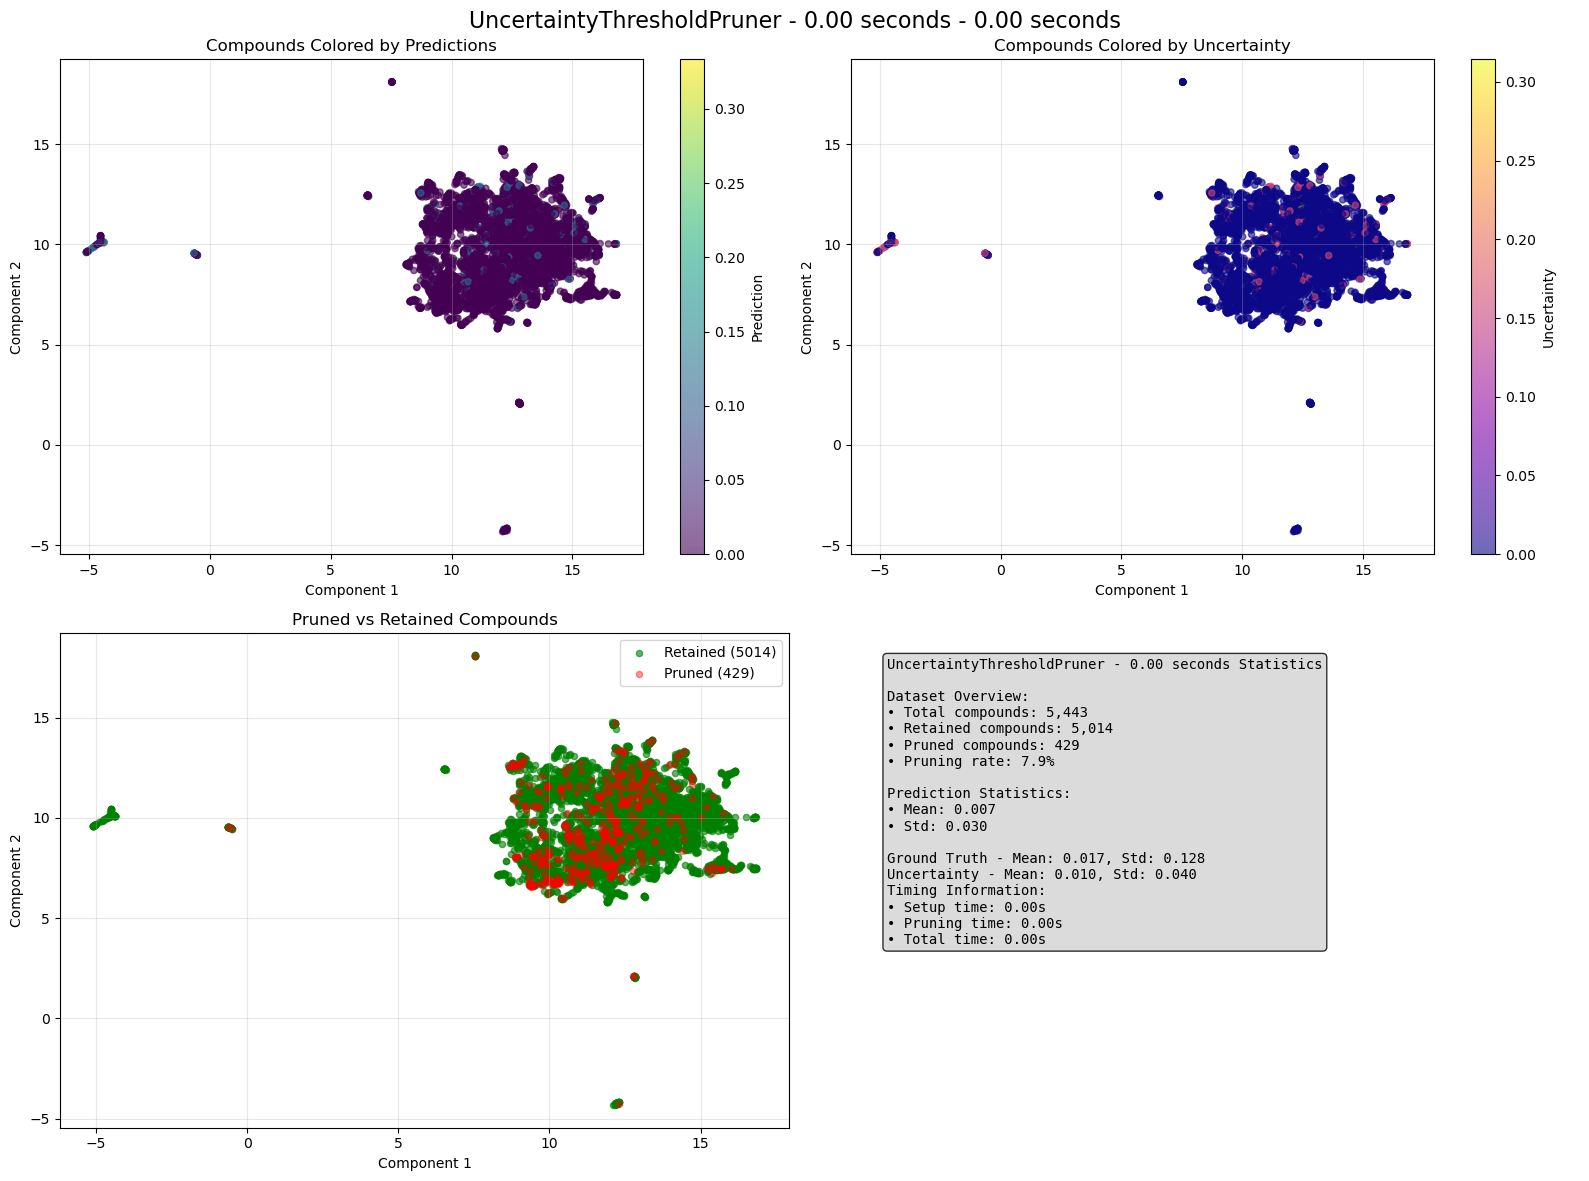

INFO:learnm8.pruning.probabilistic:PredictionThresholdPruner removed 0 compounds (0.0%) with prediction >= 0.000
INFO:__main__:Creating pruning plots for PredictionThresholdPruner - 0.00 seconds


    ✅ UncertaintyThresholdPruner completed successfully
       Pruned: 429, Retained: 5106
       Time: 0.00s

  🧪 Testing PredictionThresholdPruner...


INFO:__main__:Saved plot to plots_ADA/predictionthresholdpruner_-_0.00_seconds_analysis.png


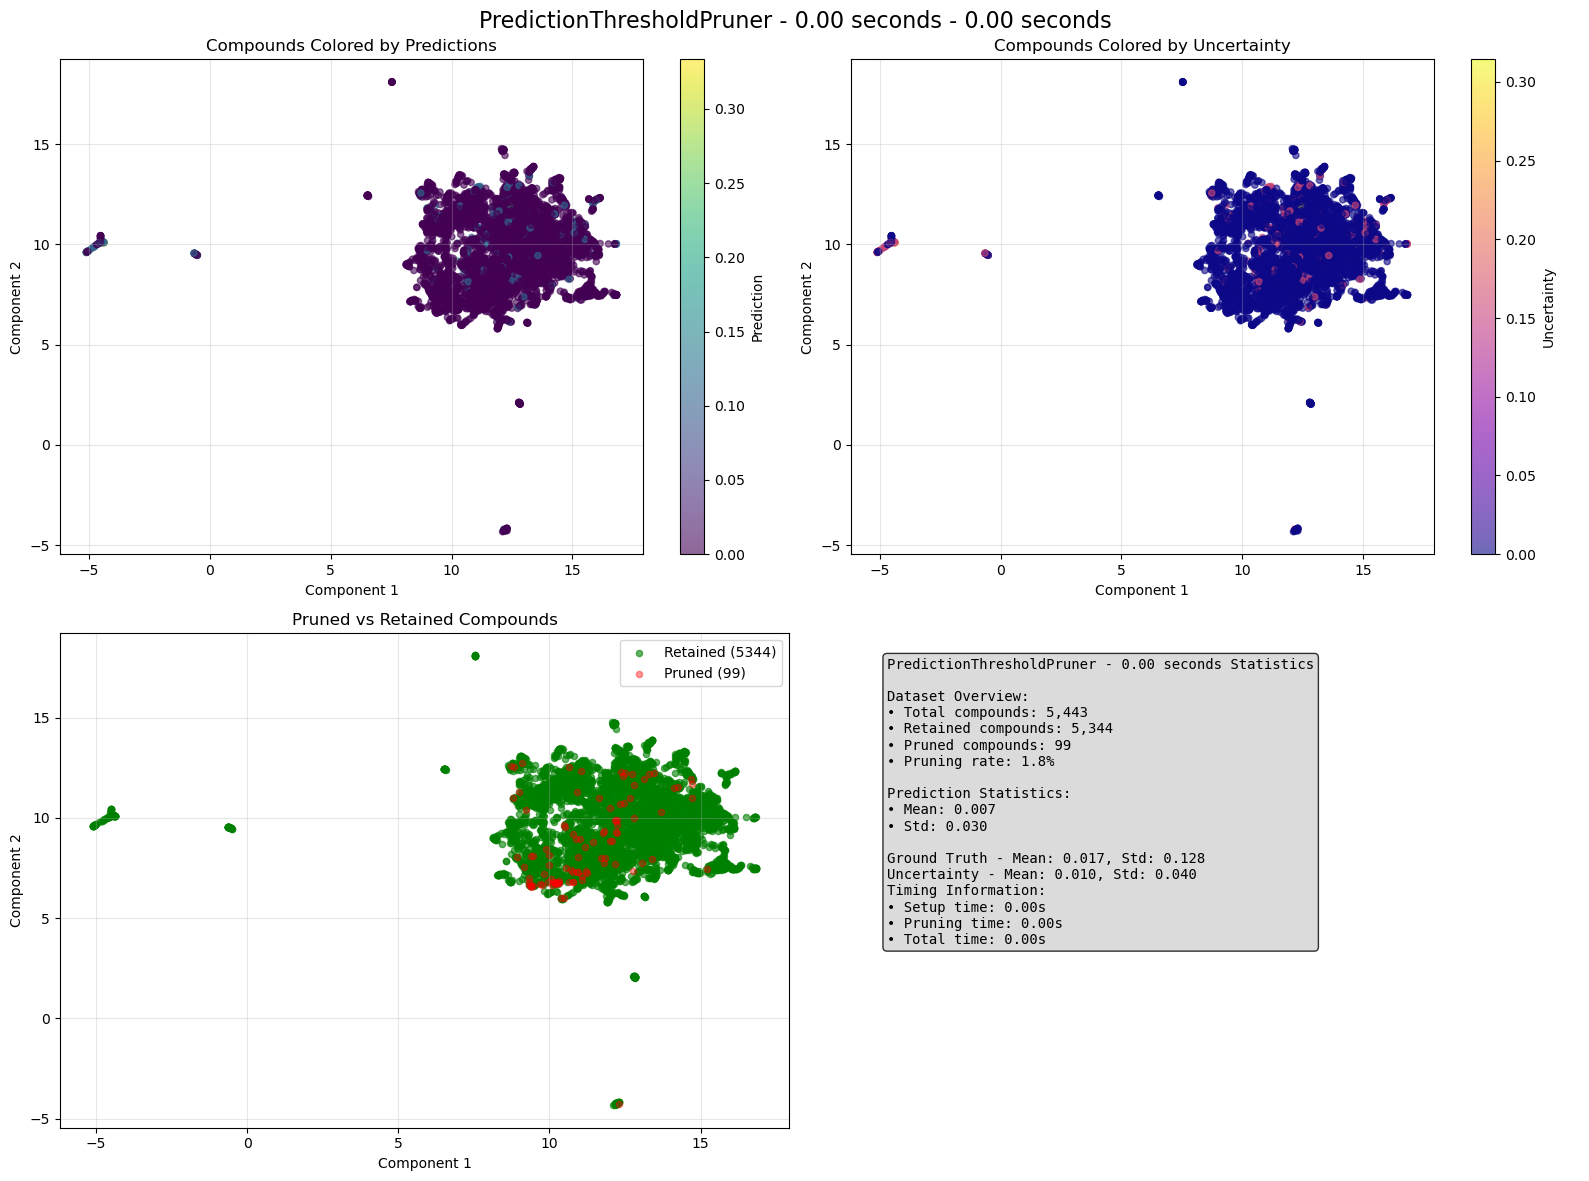

ERROR:__main__:Error testing ConfidenceIntervalPruner: ConfidenceIntervalPruner.__init__() missing 2 required positional arguments: 'target_min' and 'target_max'
INFO:learnm8.core.data_manager:Initialized DataManager with cache: .cache
INFO:validation.data_loading:Testing molecular featurization on sample compounds...
INFO:validation.data_loading:Test IDs being passed to DataManager: ['C38660894_decoy', 'C02133431_decoy', 'C38688550_decoy', 'C38688557_decoy', 'C12508742_decoy', 'C17190698_decoy', 'C38660756_decoy', 'C01313134_decoy', 'C28116964_decoy', 'C38556326_decoy']
INFO:validation.data_loading:Test SMILES being passed to DataManager: ['c1ccc(cc1)Oc2cccc(c2)[C@H]3c4ccc(cc4OC(=C3C#N)N)OC(=O)c5cccc6c5cccc6', 'Cc1ccc(cc1)[C@@H]2c3c(c4ccccc4[nH]3)C[C@@H]5N2C(=O)N(C5=O)c6ccccc6C(=O)NC7CCCC7', 'Cc1c2cc(ccc2oc1C(=O)Oc3ccc4c(c3)OC(=C([C@H]4c5cccc6c5cccc6)C#N)N)Cl', 'Cc1cc(c2c(c(oc2c1)C(=O)Oc3ccc4c(c3)OC(=C([C@@H]4c5cccc6c5cccc6)C#N)N)C)C', 'CCn1c2ccccc2c3c1ccc(c3)C[NH+]4CCC(CC4)[C@]5(C(=O

    ✅ PredictionThresholdPruner completed successfully
       Pruned: 99, Retained: 5443
       Time: 0.00s

  🧪 Testing ConfidenceIntervalPruner...
    ❌ ConfidenceIntervalPruner failed: ConfidenceIntervalPruner.__init__() missing 2 required positional arguments: 'target_min' and 'target_max'

🔍 Processing HIVPR dataset...

🧪 Testing Pruning Strategies on HIVPR Dataset
📊 Step 1: Loading HIVPR dataset...
Found Activity column - enrichment calculations will be performed
Loaded 36286 compounds for benchmarking
Target column: Activity
Loaded 36286 compounds
Target column: Activity
Score range: 0.00 to 1.00
⚙️  Step 2: Setting up data manager...


In [ ]:
# Cell 5: Run Validation on All Datasets
print("🚀 Starting Probabilistic Pruning Validation")
print("=" * 60)

all_results = {}
start_time = datetime.now()

# Test each dataset
for dataset_name, dataset_config in DATASETS.items():
    print(f"\n🔍 Processing {dataset_name} dataset...")
    
    # Check if dataset file exists
    if not Path(dataset_config["path"]).exists():
        print(f"⚠️  Dataset file not found: {dataset_config['path']}")
        print(f"   Skipping {dataset_name}")
        continue
    
    # Test pruning strategies on this dataset
    dataset_results = test_pruning_on_dataset(dataset_name, dataset_config, PRUNING_CONFIGS)
    all_results[dataset_name] = dataset_results

total_time = datetime.now() - start_time
print(f"\n{'='*60}")
print(f"🎉 Validation Complete! Total time: {total_time.total_seconds():.2f} seconds")
print(f"{'='*60}")

In [ ]:
# Cell 6: Summary and Analysis
print("📊 VALIDATION SUMMARY")
print("=" * 50)

# Create summary statistics
summary_data = []
for dataset_name, dataset_results in all_results.items():
    print(f"\n📋 {dataset_name} Results:")
    for strategy_name, result in dataset_results.items():
        if result['success']:
            pruning_rate = result['pruning_rate'] * 100
            timing = result['timing']['total_time']
            print(f"  ✅ {strategy_name:25} | Pruning: {pruning_rate:5.1f}% | Time: {timing:6.2f}s")
            
            summary_data.append({
                'Dataset': dataset_name,
                'Strategy': strategy_name,
                'Success': True,
                'Pruned_Count': result['pruned_count'],
                'Retained_Count': result['retained_count'],
                'Total_Count': result['total_count'],
                'Pruning_Rate': pruning_rate,
                'Time_Seconds': timing
            })
        else:
            print(f"  ❌ {strategy_name:25} | Error: {result['error']}")
            summary_data.append({
                'Dataset': dataset_name,
                'Strategy': strategy_name,
                'Success': False,
                'Error': result['error']
            })

# Create summary DataFrame
if summary_data:
    summary_df = pd.DataFrame(summary_data)
    print(f"\n📈 Overall Statistics:")
    
    # Success rate by strategy
    success_by_strategy = summary_df.groupby('Strategy')['Success'].agg(['count', 'sum']).reset_index()
    success_by_strategy['Success_Rate'] = (success_by_strategy['sum'] / success_by_strategy['count'] * 100).round(1)
    print(f"\n🎯 Success Rate by Strategy:")
    for _, row in success_by_strategy.iterrows():
        print(f"  {row['Strategy']:25} | {row['Success_Rate']:5.1f}% ({row['sum']}/{row['count']})")
    
    # Average timing for successful runs
    successful_runs = summary_df[summary_df['Success'] == True]
    if len(successful_runs) > 0:
        timing_by_strategy = successful_runs.groupby('Strategy')['Time_Seconds'].agg(['mean', 'std']).reset_index()
        print(f"\n⏱️  Average Timing by Strategy (successful runs):")
        for _, row in timing_by_strategy.iterrows():
            mean_time = row['mean']
            std_time = row['std'] if not pd.isna(row['std']) else 0
            print(f"  {row['Strategy']:25} | {mean_time:6.2f}s ± {std_time:5.2f}s")
        
        # Average pruning rates
        pruning_by_strategy = successful_runs.groupby('Strategy')['Pruning_Rate'].agg(['mean', 'std']).reset_index()
        print(f"\n🔧 Average Pruning Rate by Strategy:")
        for _, row in pruning_by_strategy.iterrows():
            mean_rate = row['mean']
            std_rate = row['std'] if not pd.isna(row['std']) else 0
            print(f"  {row['Strategy']:25} | {mean_rate:5.1f}% ± {std_rate:4.1f}%")

print(f"\n📁 Plots saved to individual plots_{{dataset_name}} directories")
print(f"🎉 Probabilistic Pruning Validation Complete!")

In [ ]:
# Cell 7: Cleanup
print("🧹 Cleaning up temporary files...")

import shutil
import glob

# Clean up any remaining cache directories
cache_dirs = glob.glob("./.cache*")
for cache_dir in cache_dirs:
    try:
        shutil.rmtree(cache_dir, ignore_errors=True)
        print(f"  Removed: {cache_dir}")
    except:
        pass

# Clean up temporary data manager directories
temp_dirs = glob.glob("./data_*")
for temp_dir in temp_dirs:
    try:
        shutil.rmtree(temp_dir, ignore_errors=True)
        print(f"  Removed: {temp_dir}")
    except:
        pass

print("✅ Cleanup complete!")
print("\n🎯 Probabilistic Pruning validation finished successfully!")
print("📊 Check the plots_* directories for detailed visualizations.")